# 📧 Email Spam Classification Project
**Course:** Machine Learning
**Model:** Optimized Multinomial Naive Bayes

---
**Project Structure:**
The project logic is modularized inside the `src` directory to maintain clean code:
1. `data_loader.py`: Handles dataset paths and loading.
2. `data_prep.py`: Text cleaning (Regex, Stop-words) and TF-IDF Vectorization.
3. `model_logic.py`: Model initialization, Grid Search Optimization, and predictions.
4. `eval_plots.py`: Metric calculations and Explainability visualizations.


# Part 1: Initialization & Data Loading

In [10]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# Importing the functions from src
from src.data_loader import load_datasets
from src.preprocessing import clean_text, vectorize_data, encode_labels
from src.model_logic import train_and_evaluate_model
from src.eval_plots import evaluate_full

print("Loading datasets...")
train_df, test_df = load_datasets()

print("Encoding categorical labels to binary integers...\n")
train_df = encode_labels(train_df, 'label')
test_df = encode_labels(test_df, 'label')

#Preview of the data
print("Train Set Sample:")
display(train_df.head(5))
print("Test Set Sample:")
display(test_df.head(5))

Loading datasets...
Datasets loaded successfully!
Encoding categorical labels to binary integers...

Train Set Sample:


,text,label
0,Congratulations! You won a tablet. Click here ...,1
1,Happy Birthday! Have a great year ahead 2cS1N1R7,0
2,Can you send me the project files? TSldiSa0,0
3,Final reminder: Your loan of ₹2708 is approved...,1
4,Exclusive deal on bike. Order before it ends v...,1


Test Set Sample:


,text,label
0,Win a brand new iPhone by entering this contes...,1
1,Claim your cashback of ₹9191 today pW4fecEd,1
2,"Hi, can we reschedule our meeting to tomorrow?...",0
3,Congratulations! You won a laptop. Click here ...,1
4,You have been selected for a free gift card. R...,1


# Part 2: Text Preprocessing & Vectorization

In [11]:
print("1. Cleaning text data (This might take a few seconds)...")
# Applying the cleaning logic you built
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

print("2. Transforming text into binary feature vectors...")
# Using the binary=True CountVectorizer logic
X_train, X_test, vectorizer = vectorize_data(train_df['cleaned_text'], test_df['cleaned_text'])

# Defining our targets
y_train = train_df['label']
y_test = test_df['label']

print(f"\nPreprocessing Completed!")
print(f"Final feature matrix shape: {X_train.shape}")

1. Cleaning text data (This might take a few seconds)...
2. Transforming text into binary feature vectors...

Preprocessing Completed!
Final feature matrix shape: (10000, 2559)


# Part 3: Model Training & Hyperparameter Tuning

In [5]:
print("Initializing Grid Search CV for Multinomial Naive Bayes...\n")

# This will run the 5-fold cross-validation and find the best alpha
best_model, metrics, grid_search = train_and_evaluate_model(X_train, y_train, X_test, y_test)

Initializing Grid Search CV for Multinomial Naive Bayes...

Starting Grid Search for optimization (CV=5)...
Optimization complete! Best params: {'alpha': 0.01}

----------------------------------------
Train Result (Optimized Model):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
----------------------------------------
Test Result (Optimized Model):
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
----------------------------------------


# Part 4: Final Evaluation & Visualizations

In [ ]:
print("Generating final evaluation results and explainability charts...")

# Here we will see WHY the model is so perfect
final_metrics, fig_cm, fig_feat = evaluate_full(best_model, vectorizer, X_test, y_test)

plt.show()

# Part 5: Model Prediction & Performance Evaluation (Test Set)

In [6]:
# --- Section 5.1: Feature Engineering Walkthrough ---
# Selecting 2 representative examples from the test set
sample_indices = [5, 15]

print("Step 5.1: Visualizing the Feature Engineering process\n")

for idx in sample_indices:
    raw_text = test_df.iloc[idx]['text']
    cleaned = clean_text(raw_text) # Your cleaning function

    # Transform to binary vector and find which words 'triggered' the model
    vectorized_sample = vectorizer.transform([cleaned])
    # Get the names of the words that are present (value = 1)
    active_words = [vectorizer.get_feature_names_out()[i] for i in vectorized_sample.indices]

    print(f"--- Example Index {idx} ---")
    print(f"RAW TEXT: {raw_text[:150]}...")
    print(f"CLEANED TEXT: {cleaned[:150]}...")
    print(f"ACTIVE FEATURES (Binary 1s): {active_words}")
    print("-" * 50)

# --- Section 5.2: First 5 Predictions on Test Set ---
import pandas as pd

# Generate predictions for the whole test set
y_pred_test = best_model.predict(X_test)

# Create a comparison table for the first 5 rows
# Mapping 1 back to 'Spam' and 0 to 'Not Spam' for readability
inv_map = {1: 'Spam', 0: 'Not Spam'}

comparison_df = pd.DataFrame({
    'Actual Label': [inv_map[label] for label in y_test.iloc[:5]],
    'Predicted Label': [inv_map[label] for label in y_pred_test[:5]],
    'Correct?': y_test.iloc[:5].values == y_pred_test[:5]
})

print("Step 5.2: First 5 Classification Results")
display(comparison_df)

# --- Section 5.3: Overall Quality Assessment ---
from sklearn.metrics import classification_report, f1_score

print("Step 5.3: Final Model Quality Metrics\n")

# Detailed report
print("Full Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Not Spam', 'Spam']))

# Highlighting the specific metric requested by HIT
f1_spam = f1_score(y_test, y_pred_test, pos_label=1)
print(f"\nFinal F1-Score for SPAM class: {f1_spam:.4f}")

Step 5.1: Visualizing the Feature Engineering process

--- Example Index 5 ---
RAW TEXT: Happy Birthday! Have a great year ahead 49n2goeq...
CLEANED TEXT: happy birthday great year ahead...
ACTIVE FEATURES (Binary 1s): ['ahead', 'birthday', 'great', 'happy', 'year']
--------------------------------------------------
--- Example Index 15 ---
RAW TEXT: Let's catch up over coffee this weekend PkSoNOkZ...
CLEANED TEXT: lets catch coffee weekend pksonokz...
ACTIVE FEATURES (Binary 1s): ['catch', 'coffee', 'lets', 'weekend']
--------------------------------------------------
Step 5.2: First 5 Classification Results


,Actual Label,Predicted Label,Correct?
0,Spam,Spam,True
1,Spam,Spam,True
2,Not Spam,Not Spam,True
3,Spam,Spam,True
4,Spam,Spam,True


Step 5.3: Final Model Quality Metrics

Full Classification Report:
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00       503
        Spam       1.00      1.00      1.00       497

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Final F1-Score for SPAM class: 1.0000


# Part 6: Extensions & Experiment Management (Bonuses)

Step 6.1: Results of the Cartesian product of all permutations (Grid Search)


,param_alpha,mean_test_score,std_test_score,rank_test_score
0,0.01,1.0,0.0,1
1,0.10,1.0,0.0,1
2,0.50,1.0,0.0,1
3,1.00,1.0,0.0,1
4,2.00,1.0,0.0,1
5,5.00,1.0,0.0,1
6,10.00,1.0,0.0,1



Conclusion: The best alpha is 0.01 with a cross-validation score of 1.0000
Step 6.2: Understanding the model logic (Top 15 words per class)


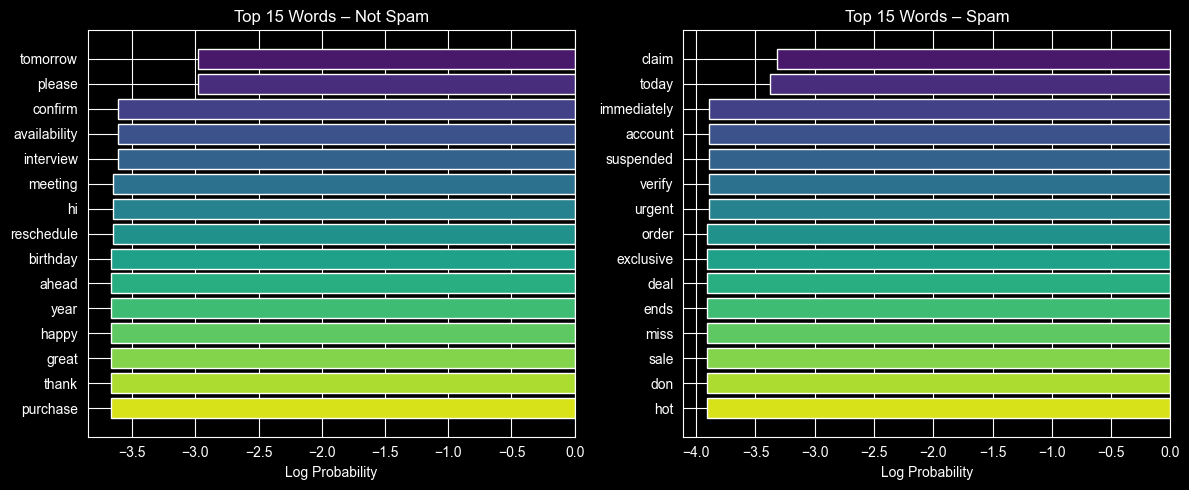

In [7]:
# Displaying the Grid Search results table
print("Step 6.1: Results of the Cartesian product of all permutations (Grid Search)")

# Converting the results into a DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Selecting the most important columns to show the 'Science' behind the choices
display_columns = ['param_alpha', 'mean_test_score', 'std_test_score', 'rank_test_score']
experiment_table = results_df[display_columns].sort_values(by='rank_test_score')

display(experiment_table)

print(f"\nConclusion: The best alpha is {grid_search.best_params_['alpha']} "
      f"with a cross-validation score of {grid_search.best_score_:.4f}")

# We already have this visualization from our eval_plots module
print("Step 6.2: Understanding the model logic (Top 15 words per class)")

# This plot was generated during Step 4/5, but we showcase it here for the bonus
# If you haven't displayed it yet, you can call it here:
from src.eval_plots import plot_top_features
fig_feat = plot_top_features(best_model, vectorizer)
plt.show()